# Knicks in Six — 02 · Feature Engineering

Turns the raw tables from notebook 01 into one training row per playoff game, **1980–present**, from the home team's perspective. Target: `home_win`.

| Feature group | Columns | Idea |
|---|---|---|
| Series context | `game_num`, `home_wins_before`, `away_wins_before`, `home_can_clinch`, `home_facing_elim`, `home_has_hca` | the series-aware part |
| Team strength | `z_margin_diff`, `z_win_pct_diff` | regular-season strength, **z-scored within season** so 1986 and 2026 are comparable (era normalization) |
| Form | `last10_margin_diff`, `close_win_rate_diff`, `rest_diff` | rolling pre-game form, shifted so no row sees its own game |
| Stars | `home_stars_playing`, `away_stars_playing` | how many of each team's top-3 regular-season scorers actually played |

All logic lives in `src/features.py`; this notebook runs it, validates it against known history, and saves `data/features/playoff_features.parquet`.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd

from src import features as F

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

## 1. Era-normalized team strength

Strength = regular-season average margin and win%, z-scored within each season. Sanity check: the all-time list should surface famous teams from *every* era, not just the high-scoring modern one.

In [2]:
games = F.load_games()
long = F.add_team_form(F.team_games_long(games))
strength = F.team_season_strength(long)

names = games.drop_duplicates("hometeamId")[["hometeamId", "hometeamCity", "hometeamName"]]
names["team"] = names["hometeamCity"] + " " + names["hometeamName"]
labeled = strength.merge(names[["hometeamId", "team"]], left_on="teamId", right_on="hometeamId")
labeled[["season", "team", "win_pct", "avg_margin", "z_margin"]].sort_values("z_margin", ascending=False).head(10)

,season,team,win_pct,avg_margin,z_margin
1021,2017,Golden State Warriors,0.817073,11.634146,2.742577
396,1996,Chicago Bulls,0.878049,12.243902,2.356397
138,1986,Boston Celtics,0.817073,9.414634,2.236560
736,2007,San Antonio Spurs,0.707317,8.426829,2.213602
1225,2024,Boston Celtics,0.792208,11.857143,2.158095
1116,2020,Milwaukee Bucks,0.767123,10.082192,2.146909
1277,2025,Seattle SuperSonics,0.819277,12.518072,2.143103
147,1986,Milwaukee Bucks,0.695122,9.012195,2.140956
991,2016,Golden State Warriors,0.890244,10.756098,2.124092
288,1992,Chicago Bulls,0.817073,10.439024,2.118095


## 2. Series context

Running series score *before* each game, clinch/elimination flags, and home-court advantage (who hosted game 1). First-round series were best-of-3 through 1983 and best-of-5 through 2002 — `_wins_needed` handles that.

Validation: the 2016 Finals (Cavs come back from 3–1) and the current 2026 Finals must match known history.

In [3]:
ctx = F.playoff_series_context(games)
view = ["gameDate", "game_num", "home_wins_before", "away_wins_before", "home_can_clinch", "home_facing_elim", "home_win"]

print("2016 Finals — GSW up 3-1, CLE wins games 5/6/7:")
display(ctx[(ctx.season == 2016) & (ctx.gameLabel == "NBA Finals")][view])

print("2026 Finals so far — should match the live series state from notebook 01 (NYK up 3-1):")
display(ctx[(ctx.season == 2026) & (ctx.gameLabel == "NBA Finals")][view])

2016 Finals — GSW up 3-1, CLE wins games 5/6/7:


,gameDate,game_num,home_wins_before,away_wins_before,home_can_clinch,home_facing_elim,home_win
43595,2016-06-02 21:00:00,1,0,0,0,0,1
43596,2016-06-05 20:00:00,2,1,0,0,0,1
43597,2016-06-08 21:00:00,3,0,2,0,0,1
43598,2016-06-10 21:00:00,4,1,2,0,0,0
43599,2016-06-13 21:00:00,5,3,1,1,0,0
43600,2016-06-16 21:00:00,6,2,3,0,1,1
43601,2016-06-19 20:00:00,7,3,3,1,1,0


2026 Finals so far — should match the live series state from notebook 01 (NYK up 3-1):


,gameDate,game_num,home_wins_before,away_wins_before,home_can_clinch,home_facing_elim,home_win
56339,2026-06-03 20:30:00,1,0,0,0,0,0
56340,2026-06-05 20:30:00,2,0,1,0,0,0
56341,2026-06-08 20:30:00,3,2,0,0,0,0
56342,2026-06-10 20:30:00,4,2,1,0,0,1


### What history says about our exact situations

Base rates straight from the 3,500+ playoff games — the "history says" half of the project. These are also a useful floor for judging the model later: it should beat just quoting these numbers.

In [4]:
def base_rate(mask, label):
    sub = ctx[mask]
    print(f"{label:>58}: {sub.home_win.mean():.1%} home win rate  (n={len(sub)})")

base_rate(ctx.game_num.notna(), "all playoff games")
base_rate(ctx.game_num == 7, "game 7s")
base_rate((ctx.home_can_clinch == 1) & (ctx.home_facing_elim == 0), "home team can clinch")
base_rate((ctx.home_facing_elim == 1) & (ctx.home_can_clinch == 0), "home team facing elimination")
base_rate((ctx.home_wins_before == 1) & (ctx.away_wins_before == 3) & (ctx.game_num == 5), "GAME 5: home team down 1-3 (SAS on Thursday)")
base_rate((ctx.home_wins_before == 3) & (ctx.away_wins_before == 2) & (ctx.game_num == 6), "GAME 6: home team up 3-2 (NYK if it gets there)")

# and the series-level number everyone quotes: how often does a 3-1 lead hold up?
g5 = ctx[(ctx.game_num == 5) & (ctx.home_wins_before.isin([1, 3])) & (ctx.home_wins_before + ctx.away_wins_before == 4)]
g5 = g5.assign(leader_id=g5.hometeamId.where(g5.home_wins_before == 3, g5.awayteamId))

last_game = ctx.sort_values("gameDate").groupby("series_id").last()
series_winner = last_game["winner"]  # winner of the last game won the series
leader_won = g5.leader_id.values == series_winner.loc[g5.series_id].values
print(f"\n{'teams up 3-1 win the series':>58}: {leader_won.mean():.1%}  (n={len(g5)})")

                                         all playoff games: 63.4% home win rate  (n=3565)
                                                   game 7s: 70.1% home win rate  (n=117)
                                      home team can clinch: 69.8% home win rate  (n=298)
                              home team facing elimination: 47.8% home win rate  (n=452)
              GAME 5: home team down 1-3 (SAS on Thursday): 69.0% home win rate  (n=84)
           GAME 6: home team up 3-2 (NYK if it gets there): 62.6% home win rate  (n=107)

                               teams up 3-1 win the series: 95.0%  (n=241)


## 3. Star availability

From 1.67M player-game rows: each team's top-3 regular-season scorers, and how many of them played in each playoff game. Captures the injury/availability signal at a basic level.

In [5]:
stars = F.star_availability()
print("distribution of stars playing per team-game:")
print(stars.stars_playing.value_counts(normalize=True).sort_index().round(3))

distribution of stars playing per team-game:
stars_playing
1    0.009
2    0.124
3    0.867
Name: proportion, dtype: float64


### 3b. Player deep-dive: Brunson & Anunoby (2025-26)

How do Jalen Brunson's and OG Anunoby's minutes and points track with the Knicks winning?

One leakage warning before reading the numbers: **same-game points/minutes are not usable as model features** — you don't know them before tip-off, and they're partly *caused* by the result (blowout wins mean starters sit in the 4th, which actually pushes the minutes-win correlation negative). They're shown here as descriptive analysis. The lagged `*_last5` versions (rolling average of the previous 5 games) *are* known pre-game and are legitimate feature candidates — their correlations show how much real predictive signal survives the lag.

In [6]:
logs = F.player_logs(["Jalen Brunson", "OG Anunoby"], season=2026)

summary = []
for p, d in logs.groupby("player"):
    summary.append({
        "player": p,
        "games": len(d),
        "ppg": d["points"].mean(),
        "mpg": d["numMinutes"].mean(),
        "corr(points, win)": d["points"].corr(d["win"]),
        "corr(minutes, win)": d["numMinutes"].corr(d["win"]),
        "corr(points_last5, win)": d["points_last5"].corr(d["win"]),
        "corr(minutes_last5, win)": d["minutes_last5"].corr(d["win"]),
    })
pd.DataFrame(summary).round(3)

,player,games,ppg,mpg,"corr(points, win)","corr(minutes, win)","corr(points_last5, win)","corr(minutes_last5, win)"
0,Jalen Brunson,92,26.315,35.149,0.046,-0.009,-0.065,-0.027
1,OG Anunoby,84,17.250,32.893,0.286,-0.083,0.079,-0.085


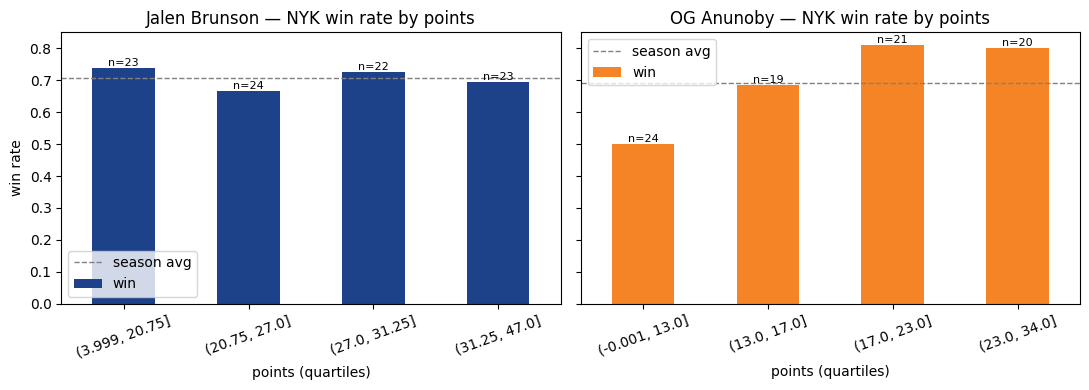

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (p, d) in zip(axes, logs.groupby("player")):
    buckets = pd.qcut(d["points"], 4)
    wr = d.groupby(buckets, observed=True)["win"].mean()
    counts = d.groupby(buckets, observed=True).size()
    wr.plot.bar(ax=ax, color="#1d428a" if "Brunson" in p else "#f58426", rot=20)
    ax.axhline(d["win"].mean(), ls="--", c="gray", lw=1, label="season avg")
    for i, (v, n) in enumerate(zip(wr, counts)):
        ax.annotate(f"n={n}", (i, v), ha="center", va="bottom", fontsize=8)
    ax.set_title(f"{p} — NYK win rate by points")
    ax.set_xlabel("points (quartiles)")
    ax.set_ylabel("win rate")
    ax.legend()
plt.tight_layout()

**Addendum — star play time vs winning, league-wide.** The Brunson/OG minutes numbers above aren't a Knicks quirk. Across every team's top-3 scorers since 1980, the correlation between a star's minutes and his team winning that game is ~zero, and the quartile pattern is a slight inverted U (moderate minutes look best, heavy minutes don't). Two causal stories cancel out: blowout wins → star sits early (few minutes, win), tight/trailing games → star plays 40+ (many minutes, coin flip). Minutes are a coaching *response* to the game, not a driver of it. Conclusion for the model: star **availability** is a feature; star **workload** is not.

In [8]:
from src.data import load_raw

ps = load_raw("PlayerStatistics.csv",
              usecols=["personId", "gameId", "playerteamId", "gameType", "numMinutes", "points", "win"])
ps["season"] = F._season_from_game_id(ps["gameId"])
ps = ps[(ps["season"] >= 1980) & ps["win"].notna()]
ps["numMinutes"] = pd.to_numeric(ps["numMinutes"], errors="coerce").fillna(0)
ps["win"] = ps["win"].astype(int)

league_top3 = (
    ps[ps["gameType"] == "Regular Season"]
    .groupby(["season", "playerteamId", "personId"])["points"].sum().reset_index()
    .sort_values("points", ascending=False)
    .groupby(["season", "playerteamId"]).head(3)[["season", "playerteamId", "personId"]]
)
star_games = ps.merge(league_top3, on=["season", "playerteamId", "personId"])
star_games = star_games[star_games["numMinutes"] > 0]

for st in ["Regular Season", "Playoffs"]:
    d = star_games[star_games["gameType"] == st]
    print(f"{st}: corr(minutes, win) = {d.numMinutes.corr(d.win):+.3f}   (n={len(d):,} star-games)")
    wr = d.groupby(pd.qcut(d["numMinutes"], 4), observed=True)["win"].mean()
    print("   win rate by minutes quartile:", "  ".join(f"{v:.1%}" for v in wr), "\n")

Regular Season: corr(minutes, win) = +0.021   (n=277,799 star-games)
   win rate by minutes quartile: 49.3%  52.2%  51.9%  50.2% 

Playoffs: corr(minutes, win) = +0.010   (n=19,886 star-games)
   win rate by minutes quartile: 49.4%  51.8%  51.1%  49.7% 



### 3c. Finals comp: Brunson vs Curry

A comp for Brunson's Finals run: Stephen Curry — another sub-6'3" guard who is his team's offensive engine and the player opposing defenses build their whole Finals game plan around. Curry played six Finals (2015–2019, 2022); Brunson's 2026 line is through 4 games and still being written.

(`win` here is the player's team winning that Finals game, so `wins` ≈ how the series went.)

In [9]:
finals_log = F.player_logs(["Jalen Brunson", "Stephen Curry"], team_id=None)
finals_log = finals_log[finals_log["gameLabel"] == "NBA Finals"]

comp = (
    finals_log.groupby(["player", "season"])
    .agg(
        games=("points", "size"),
        wins=("win", "sum"),
        ppg=("points", "mean"),
        mpg=("numMinutes", "mean"),
        fgm=("fieldGoalsMade", "sum"),
        fga=("fieldGoalsAttempted", "sum"),
        threes_pg=("threePointersMade", "mean"),
        apg=("assists", "mean"),
    )
    .assign(fg_pct=lambda d: d.fgm / d.fga)
    .drop(columns=["fgm", "fga"])
)
comp.round(2)

games  wins    ppg    mpg  threes_pg   apg  fg_pct
player        season                                                    
Jalen Brunson 2026        4     3  29.50  38.66       2.50  5.00    0.40
Stephen Curry 2015        6     4  26.00  42.17       4.17  6.33    0.44
              2016        7     3  22.57  34.57       4.57  3.71    0.40
              2017        5     4  26.80  37.20       3.80  9.40    0.44
              2018        4     4  27.50  40.00       5.50  6.75    0.40
              2019        6     2  30.50  41.17       3.83  6.00    0.41
              2022        6     4  31.17  37.17       5.17  5.00    0.48

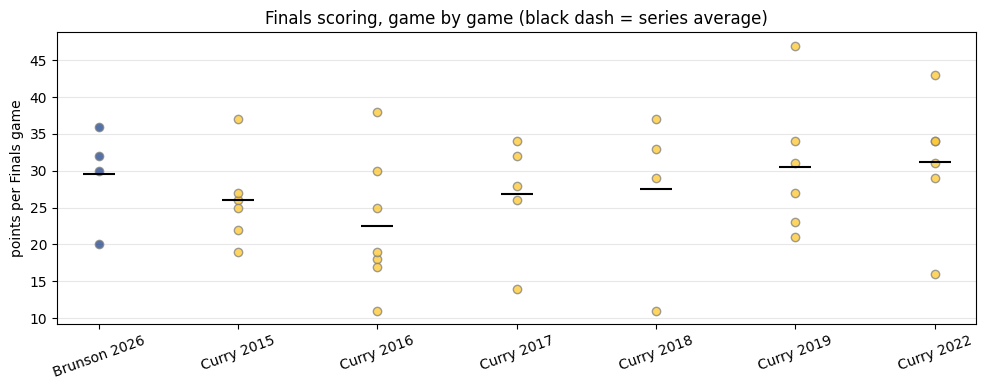

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ticks, labels = [], []
for i, ((p, s), d) in enumerate(finals_log.groupby(["player", "season"])):
    color = "#1d428a" if p == "Jalen Brunson" else "#ffc72c"
    ax.scatter([i] * len(d), d["points"], alpha=0.75, color=color, edgecolor="gray", zorder=3)
    ax.scatter(i, d["points"].mean(), marker="_", s=500, color="black", zorder=4)
    ticks.append(i)
    labels.append(f"{p.split()[-1]} {s}")
ax.set_xticks(ticks, labels=labels, rotation=20)
ax.set_ylabel("points per Finals game")
ax.set_title("Finals scoring, game by game (black dash = series average)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

## 4. Assemble and save the training table

In [11]:
train = F.build_training_table(save=True)
print(f"saved {len(train):,} rows -> {F.FEATURES_PATH}")
print(f"seasons {train.season.min()}-{train.season.max()} | home win rate {train.home_win.mean():.1%} | nulls: {int(train[F.FEATURE_COLS].isna().sum().sum())}")
train.tail(4)

saved 3,565 rows -> /Users/maddywang/git/knicks-in-six/data/features/playoff_features.parquet
seasons 1980-2026 | home win rate 63.4% | nulls: 0


,gameId,season,gameDate,gameLabel,hometeamId,awayteamId,game_num,home_has_hca,home_wins_before,away_wins_before,home_can_clinch,home_facing_elim,z_margin_diff,z_win_pct_diff,last10_margin_diff,close_win_rate_diff,rest_diff,home_stars_playing,away_stars_playing,home_win
3561,42500401,2026,2026-06-03 20:30:00,NBA Finals,1610612759,1610612752,1,1,0,0,0,0,0.323153,0.661217,-16.6,-0.111111,-5.0,3,3,0
3562,42500402,2026,2026-06-05 20:30:00,NBA Finals,1610612759,1610612752,2,1,0,1,0,0,0.323153,0.661217,-15.2,-0.111111,0.0,3,3,0
3563,42500403,2026,2026-06-08 20:30:00,NBA Finals,1610612752,1610612759,3,0,2,0,0,0,-0.323153,-0.661217,13.2,0.150097,0.0,3,3,0
3564,42500404,2026,2026-06-10 20:30:00,NBA Finals,1610612752,1610612759,4,0,2,1,0,0,-0.323153,-0.661217,11.5,0.100000,0.0,3,3,1


In [12]:
# quick signal check: point-biserial correlation of each feature with the target
train[F.FEATURE_COLS].corrwith(train[F.TARGET_COL]).sort_values(ascending=False).round(3)

z_win_pct_diff         0.286
z_margin_diff          0.277
home_has_hca           0.223
last10_margin_diff     0.202
close_win_rate_diff    0.101
home_stars_playing     0.075
home_can_clinch        0.051
rest_diff              0.046
home_wins_before       0.005
away_stars_playing    -0.019
game_num              -0.089
home_facing_elim      -0.095
away_wins_before      -0.145
dtype: float64

## 5. Feature rows for the remaining Finals games

Given NYK lead 3–1, the remaining series states are deterministic *if the game happens*: game 5 at SAS, game 6 (only if SAS win game 5) at MSG, game 7 (only if SAS also win game 6) at SAS. Notebook 03 will score these rows and chain the conditionals into P(title), P(in 5/6/7).

Simplifications (documented in `finals_scenarios`): form features frozen at post-game-4 values, equal rest assumed.

In [13]:
scenarios = F.finals_scenarios()
scenarios.round(3)

,scenario,knicks_home,game_num,home_has_hca,home_wins_before,away_wins_before,home_can_clinch,home_facing_elim,z_margin_diff,z_win_pct_diff,last10_margin_diff,close_win_rate_diff,rest_diff,home_stars_playing,away_stars_playing
0,Game 5 (SAS home),False,5,1,1,3,0,1,0.323,0.661,-11.5,-0.1,0.0,3,3
1,Game 6 (NYK home),True,6,0,3,2,1,0,-0.323,-0.661,11.5,0.1,0.0,3,3
2,Game 7 (SAS home),False,7,1,3,3,1,1,0.323,0.661,-11.5,-0.1,0.0,3,3


## Next steps

**03_model**: train the win-probability model on `playoff_features.parquet` (logistic regression baseline, time-based train/test split so we never train on the future), calibrate it, compare against the section-2 base rates, then score the three scenario rows and chain them: P(NYK win next game), P(in 6), P(in 7), P(title).